# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from xgboost import plot_importance
from matplotlib import pyplot

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

In [5]:
from platform import python_version

print(python_version())



3.10.12


In [6]:
!which python3

/usr/bin/python3


In [7]:
print(np.__version__)

1.26.3


# Define all functions

In [8]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(1, 10),
        'max_depth': Integer(1, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
 

In [9]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [10]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=24, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=6
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [11]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [12]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [13]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [14]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# XGBoost feature selection

In [15]:
tt_data = pd.read_pickle("pickle_files/training_data_bbd.pkl")
tt_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [16]:
tt_bbd_snps = tt_data.iloc[:, 1:251229]
tt_bbd_snps.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [17]:
tt_bbd_snps_dupe = tt_data.iloc[:, 1:251229]
tt_bbd_snps_dupe.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [20]:
tt_y = tt_data.iloc[:, 251241:]
tt_y.head()

,BBD
new_line,
s100_BeiJing_2013,61
s100_HeNan_2014,37
s100_HeNan_2015,43
s1014_BeiJing_2013,77
s1014_HeNan_2014,42


In [21]:
cov = tt_data.iloc[:,-12:]
cov.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,
s100_BeiJing_2013,9.5000,6.26667,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,10.2200,7.19333,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,10.2133,4.00000,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,10.3667,7.76667,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,11.8200,7.78667,73.000,2.60000,0,1,0,0,0,0,1,42


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(tt_bbd_snps, tt_y, test_size=0.1, random_state=42)

In [ ]:
#Ran this is an isolated high mem job and got the bets params
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

In [23]:
best_params = {
    'colsample_bylevel': 0.09980029725462791,
    'colsample_bytree': 0.8722795914995757,
    'gamma': 0.0003054174315433398,
    'learning_rate': 0.01,
    'max_delta_step': 12,
    'max_depth': 35,
    'min_child_weight': 8,
    'n_estimators': 123,
    'reg_alpha': 5.86344298725219e-06,
    'reg_lambda': 1.5710628243211174e-07,
    'subsample': 0.1983598808485163
}

# Run the model with the best parameters
model = xgb.XGBRegressor(**best_params)

In [24]:
#tt_bbd_snps = tt_bbd_snps.to_numpy()
#tt_y = tt_y.to_numpy() 
#Fit the modle on the entire training training set
model.fit(tt_bbd_snps, tt_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.09980029725462791, colsample_bynode=None,
             colsample_bytree=0.8722795914995757, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.0003054174315433398, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=12, max_depth=35,
             max_leaves=None, min_child_weight=8, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=123,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
#if you wan tto use the default feature importance
importances = model.feature_importances_
print(importances)
print("Median importance:", np.median(importances))
print("Features kept:", selector.get_support().sum(), "out of", len(importances))

[0. 0. 0. ... 0. 0. 0.]
Median importance: 0.0
Features kept: 251228 out of 251228


<Figure size 2000x2000 with 0 Axes>

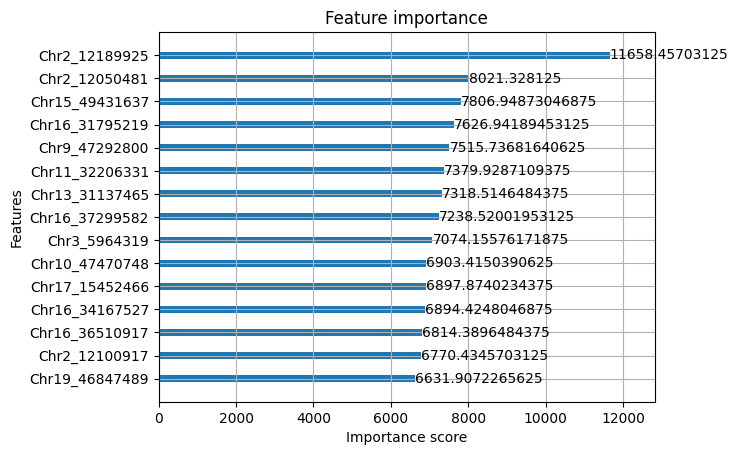

In [25]:
plt.figure(figsize = (20, 20))
plot_importance(model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [26]:
booster = model.get_booster()
importances = booster.get_score(importance_type='gain')
feature_names = booster.feature_names
importances_array = np.array([importances.get(f, 0.) for f in feature_names])

In [27]:
importances_array

array([0., 0., 0., ..., 0., 0., 0.])

In [28]:
print("Max importance:", np.max(importances_array))
print("Min importance:", np.min(importances_array))
print("Mean importance:", np.mean(importances_array))
print("Median importance:", np.median(importances_array))

Max importance: 11658.45703125
Min importance: 0.0
Mean importance: 19.52084030471025
Median importance: 0.0


In [29]:
print("Features with gain > 0:", np.sum(importances_array > 0))
print("Features with gain > mean:", np.sum(importances_array > np.mean(importances_array)))
print("Features with gain > 20:", np.sum(importances_array > 2000))

Features with gain > 0: 5862
Features with gain > mean: 5676
Features with gain > 20: 592


In [30]:
top_n = 1000 # Choose a number based on the max value and median values from abive
top_indices = np.argsort(importances_array)[::-1][:top_n]  # Sort in descending order and take first 1000
selected_features = np.array(feature_names)[top_indices]
new_data = tt_bbd_snps[selected_features]

In [155]:
# If using a threshold like mean or median or a custom thresold then use this
threshold = np.mean(importances_array)
selected_mask = importances_array > threshold
selected_features = np.array(feature_names)[selected_mask]
new_data = tt_bbd_snps[selected_features]

In [31]:
new_data.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_25050552,Chr19_5385197,Chr5_20019218,Chr1_1875859,Chr7_30016631,Chr18_54729653,Chr5_31526068,Chr18_26757646,Chr15_27699994,Chr16_11070224
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100_HeNan_2014,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100_HeNan_2015,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s1014_BeiJing_2013,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2
s1014_HeNan_2014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2


In [24]:
# Select important features and tranform (can't use this, as it use weight as importance type)
selector = SelectFromModel(model, prefit=True, threshold='median')
X_selected = selector.transform(tt_bbd_snps)

/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [25]:
# Get the names of the selected features
selected_features = tt_bbd_snps.columns[selector.get_support()]

In [29]:
# Create a new df with only the selected features
new_data = pd.DataFrame(X_selected, columns=selected_features, index=tt_bbd_snps.index)

In [157]:
new_data.head()

,Chr1_241970,Chr1_1444930,Chr1_1945717,Chr1_3234577,Chr1_3445775,Chr1_3504427,Chr1_7977377,Chr1_9872220,Chr1_10203439,Chr1_11136926,...,Chr20_35671210,Chr20_36007112,Chr20_38952655,Chr20_39880849,Chr20_40457173,Chr20_42887442,Chr20_44416558,Chr20_44426687,Chr20_47728999,Chr20_50892784
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s100_HeNan_2014,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s100_HeNan_2015,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s1014_BeiJing_2013,0,0,0,0,2,0,2,0,0,0,...,0,1,0,0,0,2,0,2,1,0
s1014_HeNan_2014,0,0,0,0,2,0,2,0,0,0,...,0,1,0,0,0,2,0,2,1,0


In [32]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 1000 entries, Chr2_12189925 to Chr16_11070224
dtypes: int64(1000)
memory usage: 19.4+ MB


In [33]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,1,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,0,0,1,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,0,0,1,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,0,0,2,0,2,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,0,0,2,0,2,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [34]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 1012 entries, Chr2_12189925 to BBD
dtypes: float64(4), int64(1008)
memory usage: 19.6+ MB


In [35]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,1,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,1,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,2,0,2,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,2,0,2,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [36]:
fs_data.to_pickle("fs_bbd_xgboost_training_data.pkl")

# All covariates

In [37]:
tt_data = pd.read_pickle("fs_bbd_xgboost_training_data.pkl")
tt_data.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,1,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,1,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,2,0,2,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,2,0,2,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [38]:
tt_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 1012 entries, Chr2_12189925 to BBD
dtypes: float64(4), int64(1008)
memory usage: 19.6+ MB


In [39]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


In [40]:
tt_all= tt_data.drop(['BBD'], axis=1)
tt_all.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [41]:
tt_all_dupe= tt_data.drop(['BBD'], axis=1)
tt_all_dupe.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


# Run models

In [42]:
X_train, X_test, y_train, y_test = train_test_split(tt_all, tt_y, test_size=0.1, random_state=42)

In [43]:
X_train.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2504,0,0,1,0,0,1,0,0,0,0,...,4.00000,93.2,1.6,0,1,0,0,0,1,0
s2862,0,0,1,0,0,0,0,0,2,0,...,4.88000,40.6,0.4,0,1,0,0,0,1,0
s382,0,0,1,2,0,0,2,0,0,0,...,7.96000,95.0,4.0,0,1,0,0,0,0,1
s78,0,0,0,0,1,2,2,0,0,0,...,3.86000,55.0,3.2,0,1,0,0,0,0,1
s691,0,0,1,1,0,0,0,0,0,0,...,6.00667,61.0,3.4,0,0,1,0,0,1,0


In [44]:
X_train = X_train.to_numpy()

In [45]:
y_train = y_train.to_numpy()

In [46]:
print("Any NaN in y:", np.isnan(y_train).any())
print("Any inf in y:", np.isinf(y_train).any())
print("Max value in y:", np.max(y_train))
print("Any NaN in X:", np.isnan(X_train).any())
print("Any inf in X:", np.isinf(X_train).any())

Any NaN in y: False
Any inf in y: False
Max value in y: 117
Any NaN in X: False
Any inf in X: False


In [47]:
print(y_train.dtype)

int64


In [48]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [50]:
tt_all = tt_all.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6632321299871121
RMSE for dataset is:6.204776955068688& mean of this fold is 46.74409448818898
this is 13.27392694843297% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6048680203243908
RMSE for dataset is:6.63398529650582& mean of this fold is 46.61417322834646
this is 14.23169143000404% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6446221396534576
RMSE for dataset is:6.280119873567979& mean of this fold is 46.31496062992126
this is 13.559592382576222% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7525528668164159
RMSE for dataset is:5.20088294845996& mean of this fold is 46.43700787401575
this is 11.19986662915498% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7563099780504612
RMSE for dataset is

In [51]:
pickle.dump(best_xgbr_model, open("xgboost_allfeats_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top1_allfeats_xgbr_bbd.pickle.dat", "rb"))

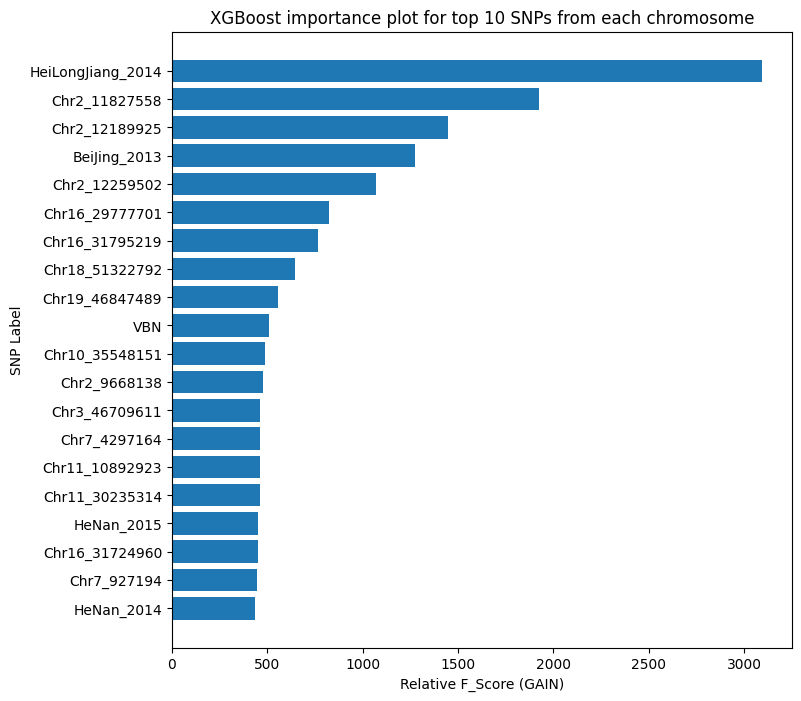

In [52]:
f_names = ['f' + str(i) for i in range(len(tt_all_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_all_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome.png')

In [53]:
explainer = shap.Explainer(best_xgbr_model)

In [54]:
shap_values = explainer(tt_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

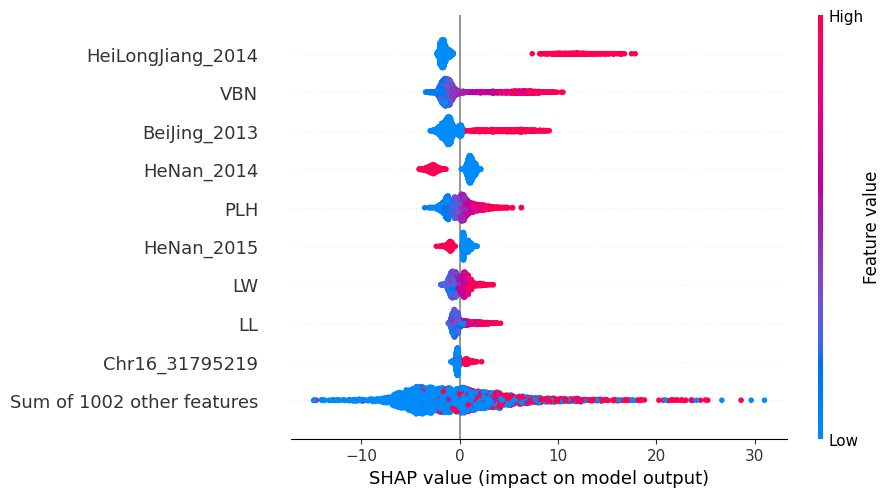

In [55]:
shap.plots.beeswarm(shap_values, show=False)

In [56]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [57]:
holdout_data = holdout_data.set_index('Line')

In [58]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [59]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [60]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [61]:
y_holdout = holdout_data.iloc[:, 251240:]

In [62]:
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [63]:
# Ensure both trainjg and holdout datasets have the same columns
tt_all_dupe, X_holdout = tt_all_dupe.align(X_holdout, join='inner', axis=1)

In [64]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 1011 entries, Chr2_12189925 to landrace
dtypes: float64(4), int64(1007)
memory usage: 4.9+ MB


In [65]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.63
RMSE of Holdout: 6.46
Mean of Holdout: 47.16
This is 13.71% of the mean pheno data
0 45 44.012287
1 39 46.64583
2 62 66.30523
3 47 51.674324
4 42 43.320534
5 40 41.83833


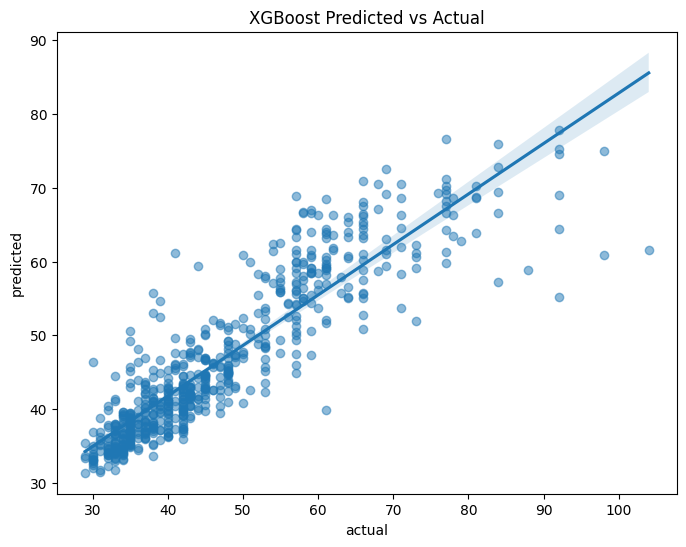

In [66]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [67]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 45 44.012287
1 39 46.64583
2 62 66.30523
3 47 51.674324
4 42 43.320534
5 40 41.83833


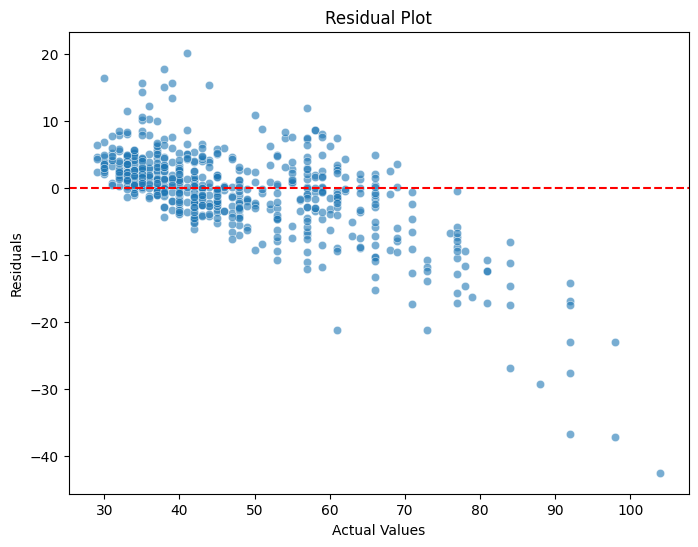

In [68]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [69]:
#### RF models

In [70]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 49), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 19), ('n_estimators', 500)])


In [71]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.5935598363226058
RMSE for dataset is:9.896753281155878& mean of this fold is 46.77952755905512
this is 21.156163385066424% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3071296079648325
RMSE for dataset is:8.951776837103274& mean of this fold is 45.08661417322835
this is 19.854622045269224% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9043543883431402
RMSE for dataset is:8.385653535417722& mean of this fold is 45.539370078740156
this is 18.414074505023788% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.785225547996279
RMSE for dataset is:9.084522093794577& mean of this fold is 45.09448818897638
this is 20.145526556869413% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.1055776732891034
RMSE for 

In [72]:
pickle.dump(best_rfr_model, open("xgboost_allfeats_rfr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -1.69
RMSE of Holdout: 9.94
Mean of Holdout: 47.16
This is 21.07% of the mean pheno data
0 45 48.07754271937715
1 39 49.80759948496498
2 62 54.628413659341035
3 47 53.64994614534812
4 42 45.62698162565442
5 40 43.292166195429715


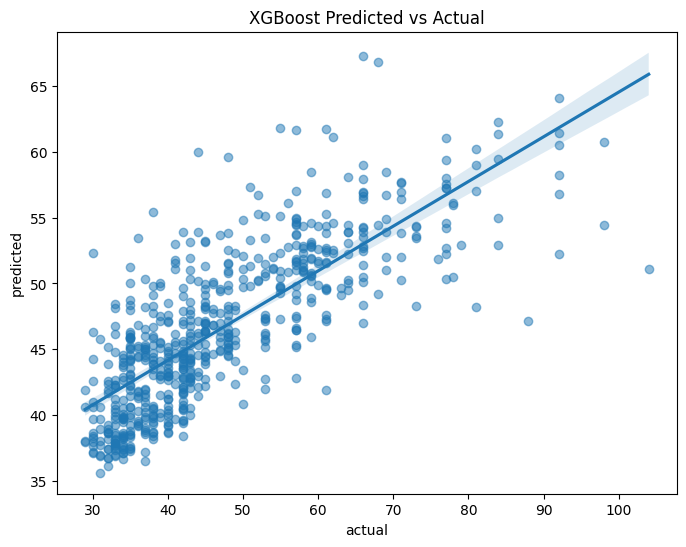

In [73]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [74]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [75]:
best_svr_model = eval_k_fold(best_svreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5796673558019282
RMSE for dataset is:7.552501407478302& mean of this fold is 45.40157480314961
this is 16.63488863596504% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.516809133240945
RMSE for dataset is:7.676795656444484& mean of this fold is 45.55905511811024
this is 16.85020823312218% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5751436718018846
RMSE for dataset is:7.46341345857396& mean of this fold is 46.468503937007874
this is 16.06123035226456% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6626966920492956
RMSE for dataset is:6.7767820196598745& mean of this fold is 45.90157480314961
this is 14.763724444580223% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5015918845589594
RMSE for dataset 

In [76]:
pickle.dump(best_svr_model, open("xgboost_allfeats_svr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: 0.55
RMSE of Holdout: 8.33
Mean of Holdout: 47.16
This is 17.66% of the mean pheno data
0 45 51.493531417884995
1 39 54.69258762672264
2 62 73.09227273971443
3 47 56.28809566495555
4 42 51.6939085177885
5 40 38.75899725192285


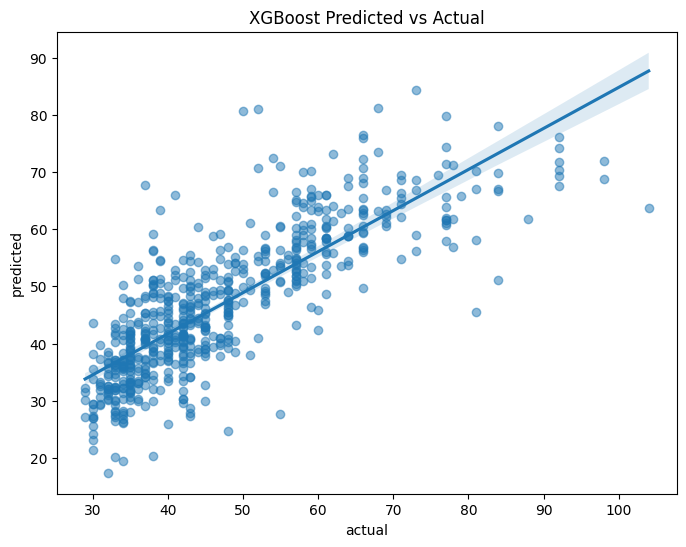

In [77]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [80]:
tt_bbd_snps = fs_data.iloc[:, 0:1000]
tt_bbd_snps.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_25050552,Chr19_5385197,Chr5_20019218,Chr1_1875859,Chr7_30016631,Chr18_54729653,Chr5_31526068,Chr18_26757646,Chr15_27699994,Chr16_11070224
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2


In [81]:
tt_bbd_snps_dupe = fs_data.iloc[:, 0:1000]
tt_bbd_snps_dupe.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_25050552,Chr19_5385197,Chr5_20019218,Chr1_1875859,Chr7_30016631,Chr18_54729653,Chr5_31526068,Chr18_26757646,Chr15_27699994,Chr16_11070224
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2


In [83]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


# Run models

In [84]:
X_train, X_test, y_train, y_test = train_test_split(tt_bbd_snps, tt_y, test_size=0.1, random_state=42)

In [85]:
X_train.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_25050552,Chr19_5385197,Chr5_20019218,Chr1_1875859,Chr7_30016631,Chr18_54729653,Chr5_31526068,Chr18_26757646,Chr15_27699994,Chr16_11070224
Line,,,,,,,,,,,,,,,,,,,,,
s2504,0,0,1,0,0,1,0,0,0,0,...,0,0,1,2,0,0,0,0,0,2
s2862,0,0,1,0,0,0,0,0,2,0,...,2,0,1,2,1,0,0,0,2,1
s382,0,0,1,2,0,0,2,0,0,0,...,0,0,0,0,0,0,1,0,0,0
s78,0,0,0,0,1,2,2,0,0,0,...,1,1,0,0,1,0,2,0,0,1
s691,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,2,1


In [86]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [87]:
#Ran this is an isolated high mem job and got the bets params
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.09681791190924606), ('colsample_bytree', 0.2893445301189143), ('gamma', 0.0018179135399913574), ('learning_rate', 0.025842583335825415), ('max_delta_step', 16), ('max_depth', 11), ('min_child_weight', 4), ('n_estimators', 112), ('reg_alpha', 2.9449371477722232e-05), ('reg_lambda', 1.1411356122467485e-07), ('subsample', 0.029708788070484098)])


In [88]:
tt_bbd_snps = tt_bbd_snps.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.5108289053711665
RMSE for dataset is:11.942270085912694& mean of this fold is 45.846456692913385
this is 26.048403622342846% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.315324006645676
RMSE for dataset is:12.59830474153089& mean of this fold is 46.874015748031496
this is 26.876947793959737% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.331197416029924
RMSE for dataset is:11.870400095756619& mean of this fold is 45.732283464566926
this is 25.956281201120706% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.3757815649256155
RMSE for dataset is:12.249588890983626& mean of this fold is 46.330708661417326
this is 26.43945936701088% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.187818716009126
RMSE f

In [89]:
pickle.dump(best_xgbr_model, open("xgboost_onlysnps_xgbr_bbd.pickle.dat", "wb"))

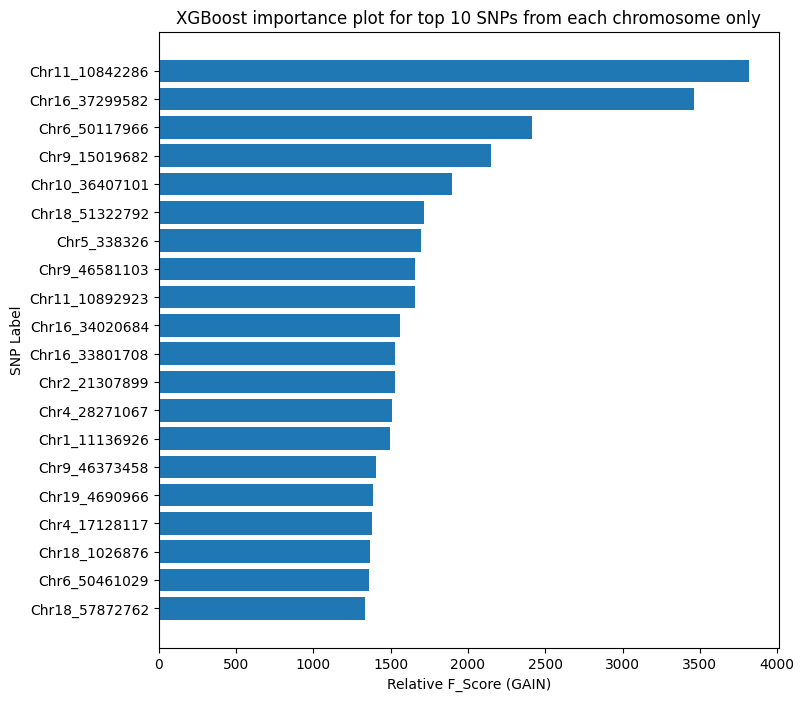

In [91]:
f_names = ['f' + str(i) for i in range(len(tt_bbd_snps_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_bbd_snps_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome only')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome only.png')

In [92]:
explainer = shap.Explainer(best_xgbr_model)

In [93]:
shap_values = explainer(tt_bbd_snps_dupe)

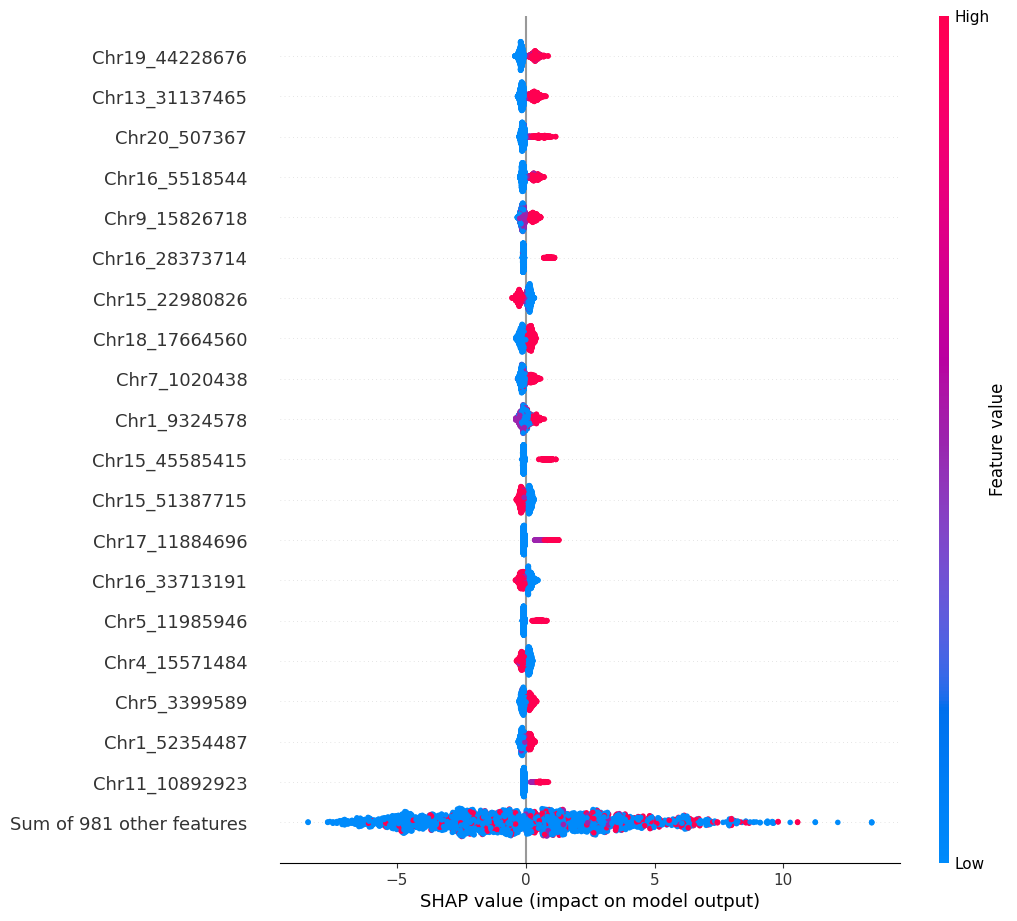

In [94]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [95]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [96]:
holdout_data = holdout_data.set_index('Line')

In [97]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [98]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [99]:
# Ensure both trainjg and holdout datasets have the same columns
tt_bbd_snps_dupe, X_holdout = tt_bbd_snps_dupe.align(X_holdout, join='inner', axis=1)

In [100]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 1000 entries, Chr2_12189925 to Chr16_11070224
dtypes: int64(1000)
memory usage: 4.8+ MB


In [101]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -8.20
RMSE of Holdout: 13.17
Mean of Holdout: 47.16
This is 27.92% of the mean pheno data
0 45 46.13674
1 39 50.72473
2 62 50.72473
3 47 44.230747
4 42 43.148964
5 40 48.104347


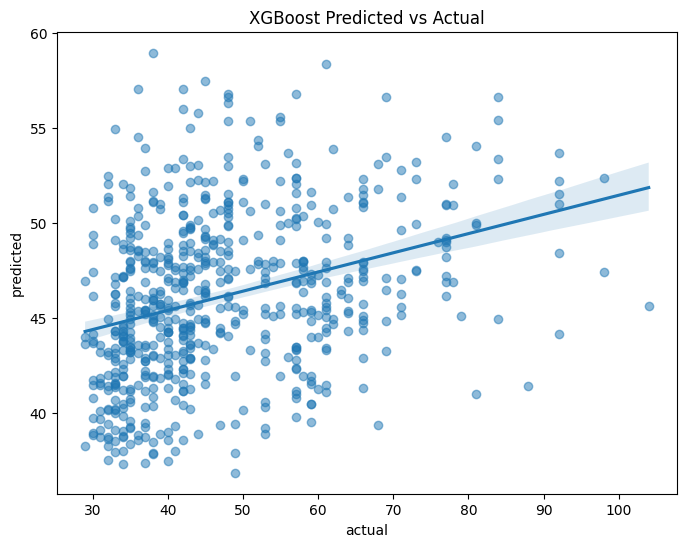

In [102]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
#### RF models

In [103]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 49), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 458)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 7), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 124)])

In [105]:
#tt_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.614126969810194
RMSE for dataset is:12.023140439323578& mean of this fold is 46.10629921259842
this is 26.077001721357608% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.860375496921687
RMSE for dataset is:11.95996122486813& mean of this fold is 45.19291338582677
this is 26.464240361673536% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.86286624391224
RMSE for dataset is:11.686191765723185& mean of this fold is 45.06299212598425
this is 25.933013353954998% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.63526600739013
RMSE for dataset is:13.03242381809794& mean of this fold is 47.003937007874015
this is 27.726238795517855% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.788994640638138
RMSE for data

In [108]:
pickle.dump(best_rfr_model, open("xgboost_onlysnps_rfr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -8.06
RMSE of Holdout: 13.10
Mean of Holdout: 47.16
This is 27.78% of the mean pheno data
0 45 50.98291268514079
1 39 47.373276281915864
2 62 47.373276281915864
3 47 47.45361460204885
4 42 46.989772052568625
5 40 48.70658291444106


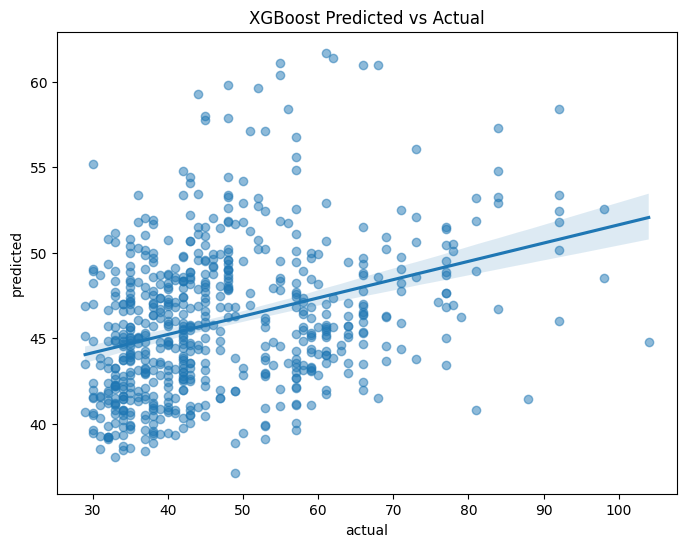

In [109]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [110]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'sigmoid')])


In [111]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.127767984666018
RMSE for dataset is:12.001739874753907& mean of this fold is 46.21259842519685
this is 25.97070990106911% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.061833982448546
RMSE for dataset is:12.988273810837477& mean of this fold is 46.653543307086615
this is 27.839844286520837% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.169152259626355
RMSE for dataset is:11.678961447573002& mean of this fold is 45.75590551181102
this is 25.524489826910536% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.146951482786642
RMSE for dataset is:11.572846740448078& mean of this fold is 45.57086614173228
this is 25.395274920724077% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.421077739353906
RMSE for

In [112]:
pickle.dump(best_svr_model, open("xgboost_onlysnps_svr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -11.92
RMSE of Holdout: 13.62
Mean of Holdout: 47.16
This is 28.89% of the mean pheno data
0 45 44.99971043901404
1 39 43.65831895106802
2 62 43.65831895106802
3 47 41.70558427936826
4 42 44.88474601771837
5 40 44.305179012167386


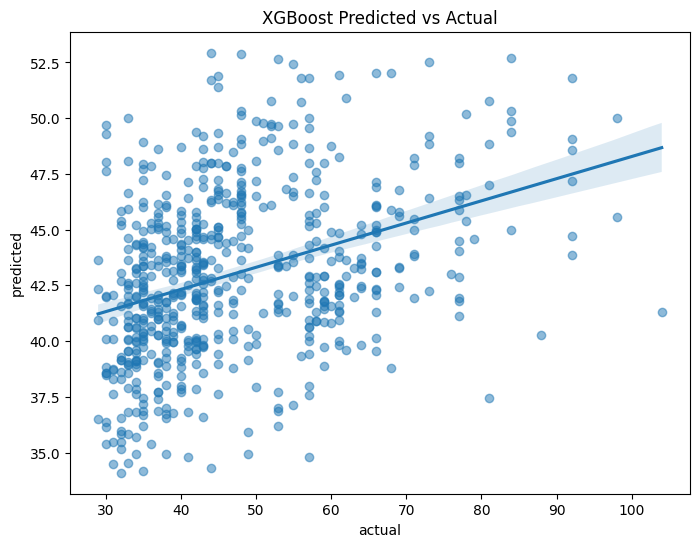

In [113]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [114]:
tt_loc= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,0,1,0,0,0,0,1


In [115]:
tt_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc_dupe.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,0,1,0,0,0,0,1


In [116]:
tt_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 1007 entries, Chr2_12189925 to landrace
dtypes: int64(1007)
memory usage: 19.6+ MB


In [117]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


In [118]:
# Run models

In [119]:
X_train, X_test, y_train, y_test = train_test_split(tt_loc, tt_y, test_size=0.1, random_state=42)

In [120]:
X_train.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2504,0,0,1,0,0,1,0,0,0,0,...,0,0,2,0,1,0,0,0,1,0
s2862,0,0,1,0,0,0,0,0,2,0,...,0,2,1,0,1,0,0,0,1,0
s382,0,0,1,2,0,0,2,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s78,0,0,0,0,1,2,2,0,0,0,...,0,0,1,0,1,0,0,0,0,1
s691,0,0,1,1,0,0,0,0,0,0,...,0,2,1,0,0,1,0,0,1,0


In [121]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [122]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [124]:
tt_loc = tt_loc.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5475332134705231
RMSE for dataset is:6.392859480117046& mean of this fold is 44.476377952755904
this is 14.373606337520844% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5591811419334425
RMSE for dataset is:6.919293820891672& mean of this fold is 45.95275590551181
this is 15.057407732235134% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.36285278192678516
RMSE for dataset is:7.9339407605386985& mean of this fold is 47.74015748031496
this is 16.619008355408454% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5892586210419851
RMSE for dataset is:6.437771436576741& mean of this fold is 45.77952755905512
this is 14.062555425614828% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5835664241663634
RMSE for da

In [125]:
pickle.dump(best_xgbr_model, open("xgboost_onlyloc_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top1_onlyloc_xgbr_bbd.pickle.dat", "rb"))

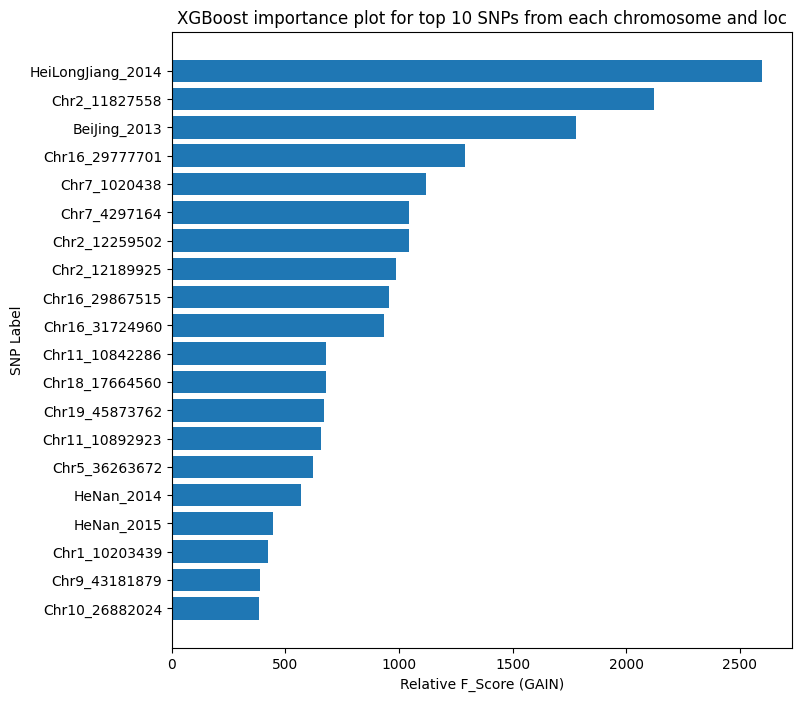

In [126]:
f_names = ['f' + str(i) for i in range(len(tt_loc_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_loc_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome and loc')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome and loc.png')

In [127]:
explainer = shap.Explainer(best_xgbr_model)

In [128]:
shap_values = explainer(tt_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

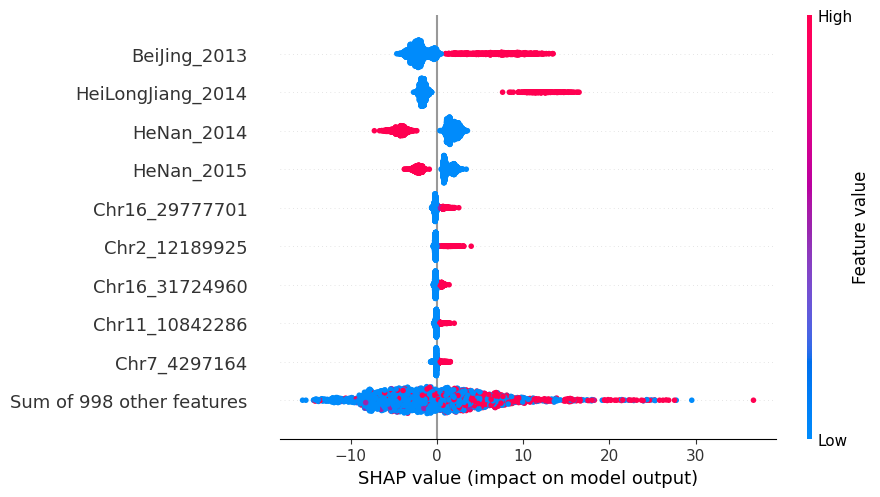

In [129]:
shap.plots.beeswarm(shap_values, show=False)

In [130]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [131]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [132]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [133]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [134]:
# Ensure both trainjg and holdout datasets have the same columns
tt_loc, X_holdout = tt_loc_dupe.align(X_holdout, join='inner', axis=1)

In [135]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 1007 entries, Chr2_12189925 to landrace
dtypes: int64(1007)
memory usage: 4.9+ MB


In [136]:
X_holdout.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,0,0,1,0,0,0,1
s101,0,2,1,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
s101,0,2,1,0,0,0,0,0,0,0,...,0,0,2,0,0,0,1,0,0,1
s1026,0,0,1,0,0,0,0,0,1,0,...,0,0,2,0,0,0,0,1,0,1
s1030,0,0,1,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,1


In [137]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.53
RMSE of Holdout: 7.03
Mean of Holdout: 47.16
This is 14.90% of the mean pheno data
0 45 47.571926
1 39 51.446564
2 62 63.108273
3 47 49.8082
4 42 42.933853
5 40 41.28153


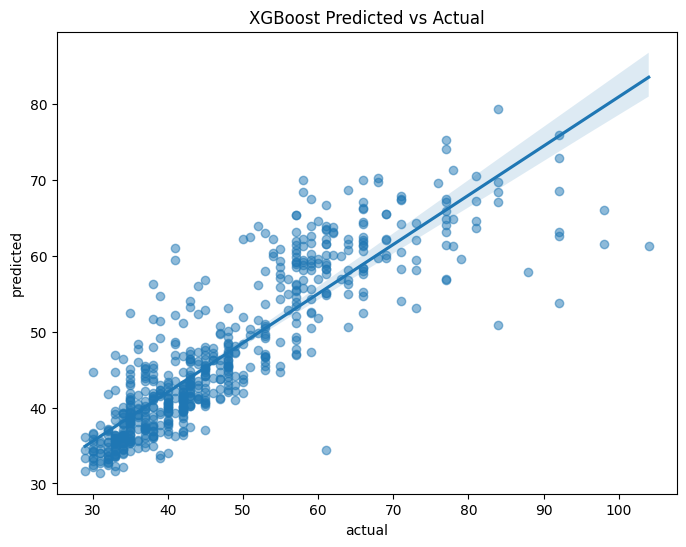

In [138]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [139]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 45 47.571926
1 39 51.446564
2 62 63.108273
3 47 49.8082
4 42 42.933853
5 40 41.28153


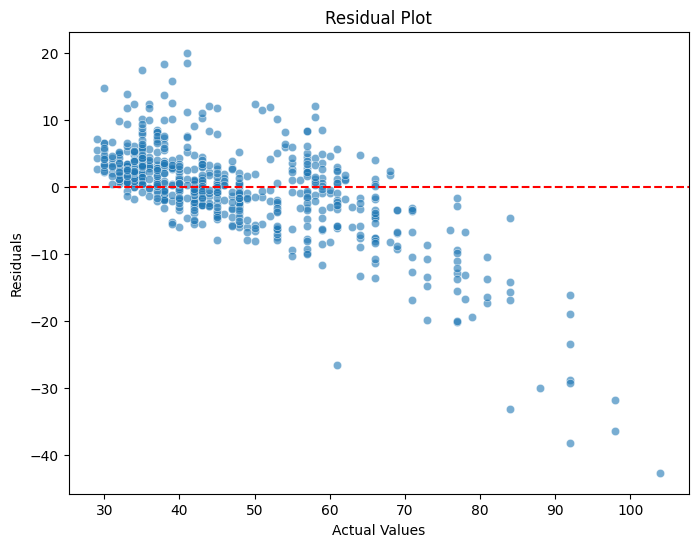

In [140]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [141]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 22), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 500)])


In [143]:
tt_loc = tt_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.414812827439648
RMSE for dataset is:10.032891872989996& mean of this fold is 45.45669291338583
this is 22.07131938107967% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.7742838954738813
RMSE for dataset is:10.654333282662435& mean of this fold is 46.8503937007874
this is 22.741181964674443% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.225763982850049
RMSE for dataset is:10.137665607104951& mean of this fold is 45.94094488188976
this is 22.066732918027746% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.381785722788142
RMSE for dataset is:10.468562387966248& mean of this fold is 46.17716535433071
this is 22.67043095356319% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.0329866823535534
RMSE for da

In [144]:
pickle.dump(best_rfr_model, open("xgboost_onlyloc_rfr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -2.88
RMSE of Holdout: 11.05
Mean of Holdout: 47.16
This is 23.42% of the mean pheno data
0 45 50.51459175339985
1 39 49.707132840750816
2 62 52.29881799766379
3 47 54.337681038616545
4 42 45.55828518020387
5 40 46.21794482374727


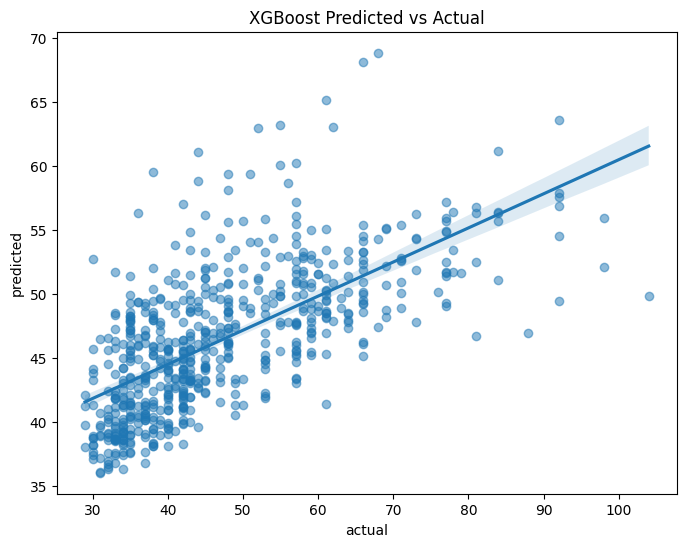

In [145]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [146]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [147]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4722055011864763
RMSE for dataset is:8.974923726329934& mean of this fold is 46.94094488188976
this is 19.119606026065615% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6075088322216042
RMSE for dataset is:7.503117851669468& mean of this fold is 44.98031496062992
this is 16.68089220414919% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5989719515843243
RMSE for dataset is:7.994839819490598& mean of this fold is 45.91338582677165
this is 17.412873556427815% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3615841576522959
RMSE for dataset is:8.939093714429038& mean of this fold is 46.22834645669291
this is 19.336823398611617% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.49460133807444995
RMSE for datas

In [148]:
pickle.dump(best_svr_model, open("xgboost_onlyloc_svr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: 0.49
RMSE of Holdout: 8.68
Mean of Holdout: 47.16
This is 18.40% of the mean pheno data
0 45 46.50014549589197
1 39 50.499833006957815
2 62 66.08457233537963
3 47 50.15360668816332
4 42 47.6350622215208
5 40 40.49966645607516


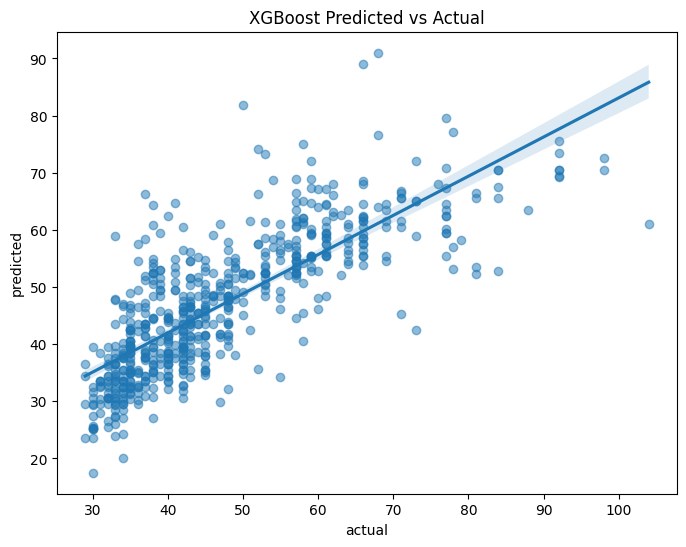

In [149]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)